In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tonnyotieno2006/sales-data/sales_data.csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/kaggle/input/datasets/tonnyotieno2006/sales-data/sales_data.csv')
print(df.head())

         date region   product  units_sold  unit_price
0  2026-01-01  North  Widget A          12        10.5
1  2026-01-02  South  Widget B           8        12.0
2  2026-01-03   East  Widget A          15        10.5
3  2026-01-04   West  Widget C           7        15.0
4  2026-01-05  North  Widget B          10        12.0


In [4]:
df['Total sales'] = df['units_sold']*df['unit_price']
product_totals = df.groupby('product')['Total sales'].sum()
print(df)
print(product_totals)

          date region   product  units_sold  unit_price  Total sales
0   2026-01-01  North  Widget A          12        10.5        126.0
1   2026-01-02  South  Widget B           8        12.0         96.0
2   2026-01-03   East  Widget A          15        10.5        157.5
3   2026-01-04   West  Widget C           7        15.0        105.0
4   2026-01-05  North  Widget B          10        12.0        120.0
5   2026-01-06  South  Widget A           9        10.5         94.5
6   2026-01-07   East  Widget C           6        15.0         90.0
7   2026-01-08   West  Widget B          11        12.0        132.0
8   2026-01-09  North  Widget C           5        15.0         75.0
9   2026-01-10  South  Widget B          14        12.0        168.0
10  2026-01-11   East  Widget A          13        10.5        136.5
11  2026-01-12   West  Widget C           4        15.0         60.0
12  2026-01-13  North  Widget A          16        10.5        168.0
13  2026-01-14  South  Widget C   

In [13]:
df.shape
df.sample(13)

,date,region,product,units_sold,unit_price,Total sales
14,2026-01-15,East,Widget B,9,12.0,108.0
3,2026-01-04,West,Widget C,7,15.0,105.0
4,2026-01-05,North,Widget B,10,12.0,120.0
1,2026-01-02,South,Widget B,8,12.0,96.0
11,2026-01-12,West,Widget C,4,15.0,60.0
10,2026-01-11,East,Widget A,13,10.5,136.5
12,2026-01-13,North,Widget A,16,10.5,168.0
8,2026-01-09,North,Widget C,5,15.0,75.0
0,2026-01-01,North,Widget A,12,10.5,126.0
7,2026-01-08,West,Widget B,11,12.0,132.0


product
Widget A    Axes(0.125,0.11;0.775x0.77)
Widget B    Axes(0.125,0.11;0.775x0.77)
Widget C    Axes(0.125,0.11;0.775x0.77)
Name: Total sales, dtype: object

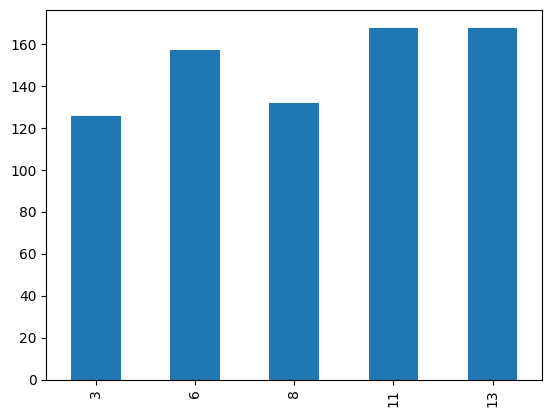

In [10]:
import matplotlib.pyplot as plt
df.groupby('product')['Total sales'].plot(
    kind='bar'
)



product
Widget A    682.5
Widget B    624.0
Widget C    375.0
Name: Total sales, dtype: float64


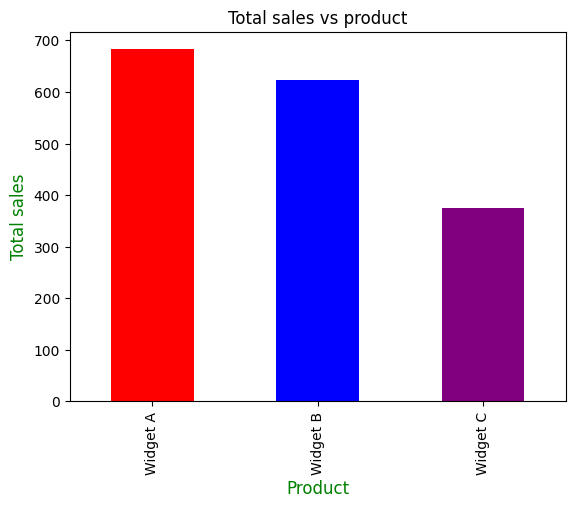

In [75]:
# Which product generated the highest total sales overall
highest_product = df.groupby('product')['Total sales'].sum()
print(highest_product)
highest_product.plot(
    kind='bar',
    color=['red','blue','purple'],
    title='Total sales vs product'
    
)
plt.xlabel('Product', color='green', fontsize=12)
plt.ylabel('Total sales', color='green', fontsize=12)
plt.show(
    
)


region
East     492.0
North    489.0
South    403.5
West     297.0
Name: Total sales, dtype: float64


Text(0.5, 0, 'region')

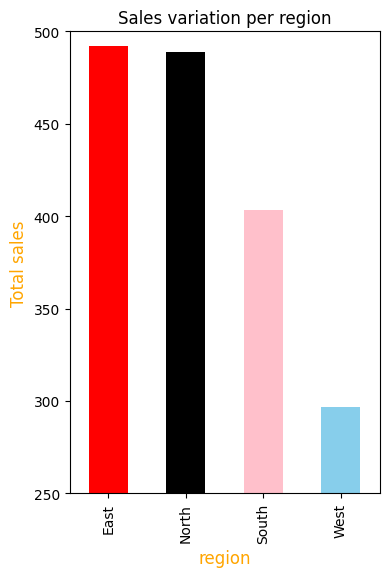

In [55]:
# Sales variation per region
Regional_sales = df.groupby('region')['Total sales'].sum()
print(Regional_sales)
Regional_sales.plot(
    kind='bar',
    figsize=(4,6),
    color= ['red', 'black', 'pink','skyblue'],
    title ='Sales variation per region',
    fontsize=10
)
plt.ylim(250,500)
#plt.yscale('log')
plt.ylabel('Total sales', color='orange', fontsize=12)
plt.xlabel('region', color='orange', fontsize=12)

                unit_price Total sales
                      mean        mean
region product                        
East   Widget A       10.5       147.0
       Widget B       12.0       108.0
       Widget C       15.0        90.0
North  Widget A       10.5       147.0
       Widget B       12.0       120.0
       Widget C       15.0        75.0
South  Widget A       10.5        94.5
       Widget B       12.0       132.0
       Widget C       15.0        45.0
West   Widget B       12.0       132.0
       Widget C       15.0        82.5


<Axes: xlabel='region,product'>

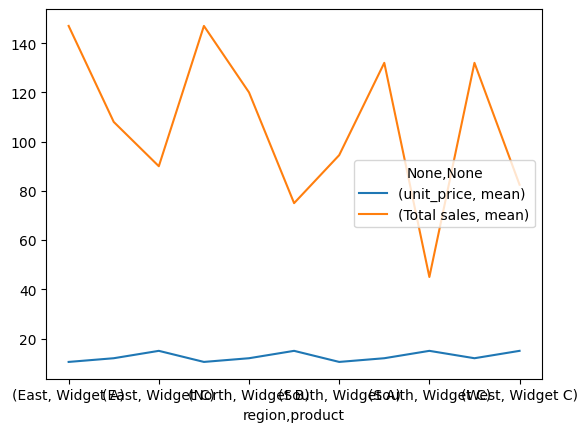

In [85]:
analyze=df.groupby(['region', 'product'])[['unit_price', 'Total sales']].agg(['mean'])
print(analyze)
analyze.plot(
    kind='line'
)

In [60]:
#Average units sold per product
Average_units_per_product = df.groupby('product')['units_sold'].mean()
print(Average_units_per_product)
Average_units_per_region = df.groupby('region')['units_sold'].mean()
print(Average_units_per_region)

product
Widget A    13.0
Widget B    10.4
Widget C     5.0
Name: units_sold, dtype: float64
region
East     10.750000
North    10.750000
South     8.500000
West      7.333333
Name: units_sold, dtype: float64


In [64]:
#Which product has the highest unit price vs. highest revenue
Product_per_unit_price = df.groupby('product')['unit_price'].max()
print(Product_per_unit_price)

product
Widget A    10.5
Widget B    12.0
Widget C    15.0
Name: unit_price, dtype: float64


In [86]:
df.groupby('product')['Total sales'].agg(['sum', 'mean', 'max'])

,sum,mean,max
product,,,
Widget A,682.5,136.5,168.0
Widget B,624.0,124.8,168.0
Widget C,375.0,75.0,105.0


<Axes: xlabel='product'>

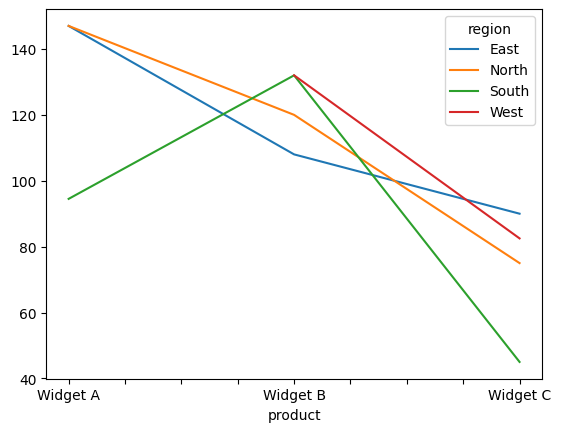

In [90]:
df.groupby(['product', 'region']).agg(
    unit_price_max=('unit_price', 'max'),
    unit_price_mean=('units_sold', 'max'),
    total_sales_sum=('Total sales', 'sum')
).reset_index()
pivot = df.pivot_table(
    index='product',
    columns='region',
    values='Total sales',
    aggfunc='mean'
)

pivot.plot(kind='line')